### Importing necessary libraries

In [484]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
from pathlib import Path

### Importing the raw data file

In [485]:
data_path = Path.cwd().parent.joinpath("data")
file_path = os.path.join(data_path, "raw",  "olkaria_unit_1.xlsx")
file = pd.ExcelFile(file_path)

# Get the sheet names
sheet_names = file.sheet_names
print("Available sheets in the file:")
for i, name in enumerate(sheet_names, 1):
    print(f"{i}. {name}")

Available sheets in the file:
1.  SUMMARY DATA FOR UNIT 1 OLK II
2. LOAD STEAM PRES FLOW TEMP DATA
3.   scrubber inlet pre,turbine te
4. data for net power to kenya pow


In [486]:
# Load the most important sheets
df_sheet_main = pd.read_excel(file_path, sheet_name=sheet_names[1])
df_sheet_turbine = pd.read_excel(file_path, sheet_name=sheet_names[2])

In [487]:
# Sheet 1
df_sheet_main.head(10)

,Dates,Gen1 Unit Load (MW),Gen2 Unit Load (MW),Gen3 Unit Load (MW),Gen1 Vent Station Steam Pressure Bar,Gen2 Vent Station Steam Pressure Bar,Gen3 Vent Station Steam Pressure Bar,Gen1 Main steam flow (T/H),Gen2 Main steam flow (T/H),Gen3 Main steam flow (T/H),Gen1 Main Steam Temp °C(Scrubber inlet),Gen2 Main Steam Temp °C(Scrubber inlet),Gen3 Main Steam Temp °C(Scrubber inlet),Gen1 Bar (Scrubber inlet) Main steam pressure,Gen2 Bar (Scrubber inlet) Main steam pressure,Gen3 Bar (Scrubber inlet) Main steam pressure,Unnamed: 16
0,2018-01-11 00:00:00,30.5,30.1,30.3,5.47,5.47,5.46,261.3,260.1,263.6,159.1,159.2,159.1,5.0,5.0,NaN,NaN
1,2018-02-11 00:00:00,30.4,25.3,25.5,5.51,5.50,5.49,264.3,220.4,217.2,159.1,159.3,159.5,5.0,5.0,5.0,NaN
2,2018-02-11 00:00:00,30.7,30.7,NaN,5.65,5.64,NaN,266.4,266.8,NaN,159.9,159.9,NaN,5.5,5.5,NaN,NaN
3,2018-03-11 00:00:00,25.7,25.7,25.7,5.66,5.69,5.69,237.3,239.2,259.2,150.4,150.3,150.3,5.6,5.6,5.6,NaN
4,2018-03-11 00:00:00,30.8,25.0,NaN,5.49,5.51,NaN,266.2,237.9,NaN,159.2,159.4,NaN,5.4,5.4,NaN,NaN
5,2018-04-11 00:00:00,25.7,25.6,25.6,5.67,5.67,5.67,241.3,241.3,241.3,160.2,160.2,160.2,5.6,5.6,5.6,NaN
6,2018-04-11 00:00:00,25.6,24.5,25.4,5.50,5.95,5.47,243.2,25.0,232.0,159.5,159.2,159.4,5.4,5.4,5.4,NaN
7,2018-05-11 00:00:00,30.8,30.9,30.3,5.47,5.46,5.47,260.7,259.4,251.9,158.0,158.5,158.9,5.3,5.3,5.3,NaN
8,2018-05-11 00:00:00,25.3,25.6,30.4,5.42,5.45,5.45,240.0,239.0,262.0,159.0,159.0,159.0,5.3,5.3,5.3,NaN
9,2018-06-11 00:00:00,30.6,30.7,30.4,5.53,5.52,5.53,263.5,260.3,265.8,159.5,159.0,158.9,5.4,5.4,5.4,NaN


In [488]:
# Sheet 2
df_sheet_turbine.head(10)

,Date,Gen1 Main Steam Temp Tubine Inlet(°C) (LH),Gen2 Main Steam Temp Tubine Inlet(°C) (LH),Gen3 Main Steam Temp Tubine Inlet(°C) (LH),Gen1 Main Steam Temp Tubine Inlet(°C) (RH),Gen2 Main Steam Temp Tubine Inlet(°C) (RH),Gen3 Main Steam Temp Tubine Inlet(°C) (RH),Gen1 Main steam Conductivity μ MHO,Gen2 Main steam Conductivity μ MHO,Gen3 Main steam Conductivity μ MHO,...,Gen2 Turbine Chest Pressure (Bar g),Gen3 Turbine Chest Pressure (Bar g),Gen1 Turbine exhaust Steam pressure Bar a,Gen2 Turbine exhaust Steam pressure Bar a,Gen3 Turbine exhaust Steam pressure Bar a,Gen1 Turbine Exhaust Steam temp,Gen2 Turbine Exhaust Steam temp,Gen3 Turbine Exhaust Steam temp,Unnamed: 19,Unnamed: 20
0,2018-01-11 00:00:00,154.6,154.8,154.6,158.5,158.7,158.5,4.0,3.4,3.2,...,5.160,5.202,0.122,0.119,0.121,50.1,49.3,49.8,NaN,NaN
1,2018-02-11 00:00:00,154.7,155.3,155.4,158.6,159.2,159.3,3.0,10.4,6.8,...,4.120,4.096,0.123,0.096,0.095,50.2,45.3,44.7,NaN,NaN
2,2018-02-11 00:00:00,155.4,155.4,NaN,159.3,159.3,NaN,4.4,4.4,NaN,...,5.329,NaN,0.125,0.125,NaN,50.1,50.7,NaN,NaN,NaN
3,2018-03-11 00:00:00,156.1,156.1,156.1,159.9,160.0,160.0,3.8,3.8,3.8,...,4.657,4.657,0.139,0.140,0.140,52.4,52.4,52.4,NaN,NaN
4,2018-03-11 00:00:00,154.8,155.0,NaN,158.7,158.8,NaN,8.0,8.2,NaN,...,4.611,NaN,0.126,0.139,NaN,50.4,52.1,NaN,NaN,NaN
5,2018-04-11 00:00:00,156.0,156.0,156.0,159.0,159.0,159.0,3.4,3.4,3.4,...,4.602,4.602,0.137,0.137,0.137,52.2,52.2,52.2,NaN,NaN
6,2018-04-11 00:00:00,155.0,159.6,155.0,158.8,158.6,155.0,4.4,6.2,7.0,...,4.550,4.461,0.143,0.139,0.131,52.9,52.7,51.6,NaN,NaN
7,2018-05-11 00:00:00,154.4,154.7,154.6,158.3,158.0,158.4,3.0,3.0,3.4,...,5.123,5.053,0.116,0.112,0.111,49.2,48.5,48.0,NaN,NaN
8,2018-05-11 00:00:00,154.5,154.5,154.2,158.3,158.3,158.0,3.6,11.6,3.4,...,4.675,5.101,0.140,0.145,0.115,52.4,53.8,49.4,NaN,NaN
9,2018-06-11 00:00:00,154.7,154.7,154.6,158.7,158.6,158.6,3.0,2.8,3.0,...,5.234,5.189,0.118,0.115,0.114,49.5,49.0,48.7,NaN,NaN


In [489]:
# Get their shapes
print(df_sheet_main.shape)
print(df_sheet_turbine.shape)


(189, 17)
(189, 21)


In [490]:
# Drop the unnamed columns
df_sheet_main = df_sheet_main.drop(columns=["Unnamed: 16"])
df_sheet_turbine = df_sheet_turbine.drop(columns = ["Unnamed: 19", "Unnamed: 20"])

In [491]:
# Create a strict preprocessing function for the individual raw slices
def preprocess_raw_slice(df, columns_list, is_turbine=False):
    df_copy = df.iloc[:, columns_list].copy()
    df_copy.columns = [
        'date', 'load_MW', 'vent_pressure_bar', 'steam_flow_th', 'scrubber_temp_C', 'scrubber_pressure_bar'
    ] if not is_turbine else [
        'date', 'lh_inlet_temp_C', 'rh_inlet_temp_C', 'conductivity_uMHO', 'chest_pressure_barg', 'exhaust_pressure_bara', 'exhaust_temp_C'
    ]

    # 1. Drop the headers/hours descriptive rows if they are present
    df_copy = df_copy[df_copy['date'] != 'HOURS']

    # 2. Drop rows where date itself is completely missing
    df_copy = df_copy.dropna(subset=['date'])

    # 3. Enforce proper datatypes immediately
    df_copy['date'] = pd.to_datetime(df_copy['date'], errors='coerce')

    # 4. Drop rows where date failed to parse (now NaNs)
    df_copy = df_copy.dropna(subset=['date'])

    # Reset index so positional alignment matches cleanly
    return df_copy.reset_index(drop=True)

# Now extract clean, standardized dataframes
gen1_load_raw = preprocess_raw_slice(df_sheet_main, [0, 1, 4, 7, 10, 13], is_turbine=False)
gen2_load_raw = preprocess_raw_slice(df_sheet_main, [0, 2, 5, 8, 11, 14], is_turbine=False)
gen3_load_raw = preprocess_raw_slice(df_sheet_main, [0, 3, 6, 9, 12, 15], is_turbine=False)

gen1_turbine_raw = preprocess_raw_slice(df_sheet_turbine, [0, 1, 4, 7, 10, 13, 16], is_turbine=True)
gen2_turbine_raw = preprocess_raw_slice(df_sheet_turbine, [0, 2, 5, 8, 11, 14, 17], is_turbine=True)
gen3_turbine_raw = preprocess_raw_slice(df_sheet_turbine, [0, 3, 6, 9, 12, 15, 18], is_turbine=True)


print("Gen1 Load raw shape:", gen1_load_raw.shape)
display(gen1_load_raw.head(5))

print("Gen2 Load raw shape:", gen2_load_raw.shape)
display(gen2_load_raw.head(5))

print("Gen3 Load raw shape:", gen3_load_raw.shape)
display(gen3_load_raw.head(5))

print("Gen1 Turbine raw shape:", gen1_turbine_raw.shape)
display(gen1_turbine_raw.head(5))

print("Gen2 Turbine raw shape:", gen2_turbine_raw.shape)
display(gen2_turbine_raw.head(5))

print("Gen3 Turbine raw shape:", gen3_turbine_raw.shape)
display(gen3_turbine_raw.head(5))


Gen1 Load raw shape: (186, 6)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar
0,2018-01-11,30.5,5.47,261.3,159.1,5.0
1,2018-02-11,30.4,5.51,264.3,159.1,5.0
2,2018-02-11,30.7,5.65,266.4,159.9,5.5
3,2018-03-11,25.7,5.66,237.3,150.4,5.6
4,2018-03-11,30.8,5.49,266.2,159.2,5.4


Gen2 Load raw shape: (186, 6)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar
0,2018-01-11,30.1,5.47,260.1,159.2,5.0
1,2018-02-11,25.3,5.50,220.4,159.3,5.0
2,2018-02-11,30.7,5.64,266.8,159.9,5.5
3,2018-03-11,25.7,5.69,239.2,150.3,5.6
4,2018-03-11,25.0,5.51,237.9,159.4,5.4


Gen3 Load raw shape: (186, 6)


...

,date,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,154.6,158.5,4.0,5.211,0.122,50.1
1,2018-02-11,154.7,158.6,3.0,5.248,0.123,50.2
2,2018-02-11,155.4,159.3,4.4,5.329,0.125,50.1
3,2018-03-11,156.1,159.9,3.8,4.662,0.139,52.4
4,2018-03-11,154.8,158.7,8.0,5.221,0.126,50.4


Gen2 Turbine raw shape: (185, 7)


,date,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,154.8,158.7,3.4,5.160,0.119,49.3
1,2018-02-11,155.3,159.2,10.4,4.120,0.096,45.3
2,2018-02-11,155.4,159.3,4.4,5.329,0.125,50.7
3,2018-03-11,156.1,160.0,3.8,4.657,0.140,52.4
4,2018-03-11,155.0,158.8,8.2,4.611,0.139,52.1


Gen3 Turbine raw shape: (185, 7)


,date,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,154.6,158.5,3.2,5.202,0.121,49.8
1,2018-02-11,155.4,159.3,6.8,4.096,0.095,44.7
2,2018-02-11,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-03-11,156.1,160.0,3.8,4.657,0.140,52.4
4,2018-03-11,NaN,NaN,NaN,NaN,NaN,NaN


In [492]:
# Define the known break-point date that causes the structural shift
shift_date = pd.to_datetime('2019-02-28')

if shift_date in gen1_load_raw['date'].values:
    # Locate where the missing row needs to sit in the turbine data sequence
    target_idx = gen1_load_raw[gen1_load_raw['date'] == shift_date].index[0]

    # Build an empty padding row matching the turbine structure
    pad_row = pd.DataFrame(columns=gen1_turbine_raw.columns)
    pad_row.loc[0] = np.nan
    pad_row['date'] = shift_date

    # Inject the padding row into Gen 1 Turbine to force subsequent positions back into alignment
    gen1_turbine_clean = pd.concat(
        [gen1_turbine_raw.iloc[:target_idx], pad_row, gen1_turbine_raw.iloc[target_idx:]],
        ignore_index=True
    )
    print(f"Successfully patched structural shift for Gen 1 Turbine data at index: {target_idx}")

Successfully patched structural shift for Gen 1 Turbine data at index: 158


In [493]:
def merge_generator_units(load_df, turbine_df):
    # Strip out the date column from turbine to avoid duplicate ._x or ._y tags
    turb_no_date = turbine_df.drop(columns=['date'], errors='ignore')
    return pd.concat([load_df, turb_no_date], axis=1)

# Assemble your target clean analytical dataframes
gen1_raw = merge_generator_units(gen1_load_raw, gen1_turbine_raw)
gen2_raw = merge_generator_units(gen2_load_raw, gen2_turbine_raw)
gen3_raw = merge_generator_units(gen3_load_raw, gen3_turbine_raw)

print("=== FINAL RESTRUCTURED SHAPES ===")
print()
print("Gen1 raw shape:", gen1_raw.shape)
display(gen1_raw.head(5))
print()
print("Gen2 raw shape:", gen2_raw.shape)
display(gen2_raw.head(5))
print()
print("Gen3 raw shape:", gen3_raw.shape)
display(gen3_raw.head(5))

=== FINAL RESTRUCTURED SHAPES ===

Gen1 raw shape: (186, 12)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,30.5,5.47,261.3,159.1,5.0,154.6,158.5,4.0,5.211,0.122,50.1
1,2018-02-11,30.4,5.51,264.3,159.1,5.0,154.7,158.6,3.0,5.248,0.123,50.2
2,2018-02-11,30.7,5.65,266.4,159.9,5.5,155.4,159.3,4.4,5.329,0.125,50.1
3,2018-03-11,25.7,5.66,237.3,150.4,5.6,156.1,159.9,3.8,4.662,0.139,52.4
4,2018-03-11,30.8,5.49,266.2,159.2,5.4,154.8,158.7,8.0,5.221,0.126,50.4



Gen2 raw shape: (186, 12)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,30.1,5.47,260.1,159.2,5.0,154.8,158.7,3.4,5.160,0.119,49.3
1,2018-02-11,25.3,5.50,220.4,159.3,5.0,155.3,159.2,10.4,4.120,0.096,45.3
2,2018-02-11,30.7,5.64,266.8,159.9,5.5,155.4,159.3,4.4,5.329,0.125,50.7
3,2018-03-11,25.7,5.69,239.2,150.3,5.6,156.1,160.0,3.8,4.657,0.140,52.4
4,2018-03-11,25.0,5.51,237.9,159.4,5.4,155.0,158.8,8.2,4.611,0.139,52.1



Gen3 raw shape: (186, 12)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,30.3,5.46,263.6,159.1,NaN,154.6,158.5,3.2,5.202,0.121,49.8
1,2018-02-11,25.5,5.49,217.2,159.5,5.0,155.4,159.3,6.8,4.096,0.095,44.7
2,2018-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-03-11,25.7,5.69,259.2,150.3,5.6,156.1,160.0,3.8,4.657,0.140,52.4
4,2018-03-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [494]:
raw_path = Path.cwd().parent / "data" / "raw"

gen1_raw.to_csv(raw_path / "gen1_raw.csv", index=False)
gen2_raw.to_csv(raw_path / "gen2_raw.csv", index=False)
gen3_raw.to_csv(raw_path / "gen3_raw.csv", index=False)

print("Saved successfully:")
print(f"  gen1_raw.csv — {gen1_raw.shape}")
print(f"  gen2_raw.csv — {gen2_raw.shape}")
print(f"  gen3_raw.csv — {gen3_raw.shape}")

Saved successfully:
  gen1_raw.csv — (186, 12)
  gen2_raw.csv — (186, 12)
  gen3_raw.csv — (186, 12)


### DATA CLEANING: Missing values, Data type

In [495]:

print("=== GEN1 DTYPES ===")
print(gen1_raw.dtypes)
print()
print("=== GEN2 DTYPES ===")
print(gen2_raw.dtypes)
print()
print("=== GEN3 DTYPES ===")
print(gen3_raw.dtypes)

=== GEN1 DTYPES ===
date                     datetime64[us]
load_MW                         float64
vent_pressure_bar               float64
steam_flow_th                   float64
scrubber_temp_C                 float64
scrubber_pressure_bar           float64
lh_inlet_temp_C                 float64
rh_inlet_temp_C                 float64
conductivity_uMHO               float64
chest_pressure_barg             float64
exhaust_pressure_bara           float64
exhaust_temp_C                  float64
dtype: object

=== GEN2 DTYPES ===
date                     datetime64[us]
load_MW                         float64
vent_pressure_bar               float64
steam_flow_th                   float64
scrubber_temp_C                 float64
scrubber_pressure_bar           float64
lh_inlet_temp_C                 float64
rh_inlet_temp_C                 float64
conductivity_uMHO               float64
chest_pressure_barg             float64
exhaust_pressure_bara           float64
exhaust_temp_C           

In [496]:
# First check null counts before doing anything
print("=== NULLS BEFORE IMPUTATION ===")
print("Gen1:")
print(gen1_raw.isnull().sum())
print()
print("Gen2:")
print(gen2_raw.isnull().sum())
print()
print("Gen3:")
print(gen3_raw.isnull().sum())
print("-" * 40)

# Drop rows where date itself is null — we cannot use a row with no date
gen1_raw = gen1_raw.dropna(subset=['date']).reset_index(drop=True)
gen2_raw = gen2_raw.dropna(subset=['date']).reset_index(drop=True)
gen3_raw = gen3_raw.dropna(subset=['date']).reset_index(drop=True)

# Columns to handle via chronological propagation
ffill_cols = [
    'load_MW', 'vent_pressure_bar', 'steam_flow_th',
    'scrubber_temp_C', 'scrubber_pressure_bar',
    'lh_inlet_temp_C', 'rh_inlet_temp_C',
    'chest_pressure_barg', 'exhaust_pressure_bara', 'exhaust_temp_C'
]

# Process each generator dataframe
for i, df in enumerate([gen1_raw, gen2_raw, gen3_raw], 1):

    # CRITICAL FIX: Chain bfill() after ffill() to handle missing values at index 0
    df[ffill_cols] = df[ffill_cols].ffill().bfill()

    # Handle conductivity imputation via localized median calculation
    # NOTE: pd.median() automatically excludes NaNs, so it's completely safe
    median_cond = df['conductivity_uMHO'].median()
    df['conductivity_uMHO'] = df['conductivity_uMHO'].fillna(median_cond)
    print(f"Gen{i} conductivity median used for fill: {median_cond}")

# Final validation sanity check
print("\n=== NULLS AFTER IMPUTATION ===")
print("Gen1:")
print(gen1_raw.isnull().sum())
print()
print("Gen2:")
print(gen2_raw.isnull().sum())
print()
print("Gen3:")
print(gen3_raw.isnull().sum())

=== NULLS BEFORE IMPUTATION ===
Gen1:
date                     0
load_MW                  8
vent_pressure_bar        8
steam_flow_th            8
scrubber_temp_C          8
scrubber_pressure_bar    9
lh_inlet_temp_C          8
rh_inlet_temp_C          8
conductivity_uMHO        9
chest_pressure_barg      8
exhaust_pressure_bara    8
exhaust_temp_C           8
dtype: int64

Gen2:
date                      0
load_MW                  10
vent_pressure_bar        10
steam_flow_th             9
scrubber_temp_C          10
scrubber_pressure_bar    10
lh_inlet_temp_C          11
rh_inlet_temp_C          11
conductivity_uMHO        10
chest_pressure_barg      10
exhaust_pressure_bara     9
exhaust_temp_C            9
dtype: int64

Gen3:
date                      0
load_MW                  11
vent_pressure_bar         9
steam_flow_th             5
scrubber_temp_C          10
scrubber_pressure_bar    11
lh_inlet_temp_C          11
rh_inlet_temp_C          12
conductivity_uMHO        10
chest_pres

In [497]:
# Save cleaned data
raw_path = Path.cwd().parent / "data" / "processed"

gen1_raw.to_csv(raw_path / "gen1_clean.csv", index=False)
gen2_raw.to_csv(raw_path / "gen2_clean.csv", index=False)
gen3_raw.to_csv(raw_path / "gen3_clean.csv", index=False)

print("Saved successfully:")
print(f"  gen1_clean.csv — {gen1_raw.shape}")
print(f"  gen2_clean.csv — {gen2_raw.shape}")
print(f"  gen3_clean.csv — {gen3_raw.shape}")

Saved successfully:
  gen1_clean.csv — (186, 12)
  gen2_clean.csv — (186, 12)
  gen3_clean.csv — (186, 12)


### Exploratory Data Analysis (EDA)

In [498]:
# Load the clean version
clean_file_path = os.path.join(data_path, "processed")
gen1_clean = pd.read_csv(os.path.join(clean_file_path, "gen1_clean.csv"))
gen2_clean = pd.read_csv(os.path.join(clean_file_path, "gen2_clean.csv"))
gen3_clean = pd.read_csv(os.path.join(clean_file_path, "gen3_clean.csv"))

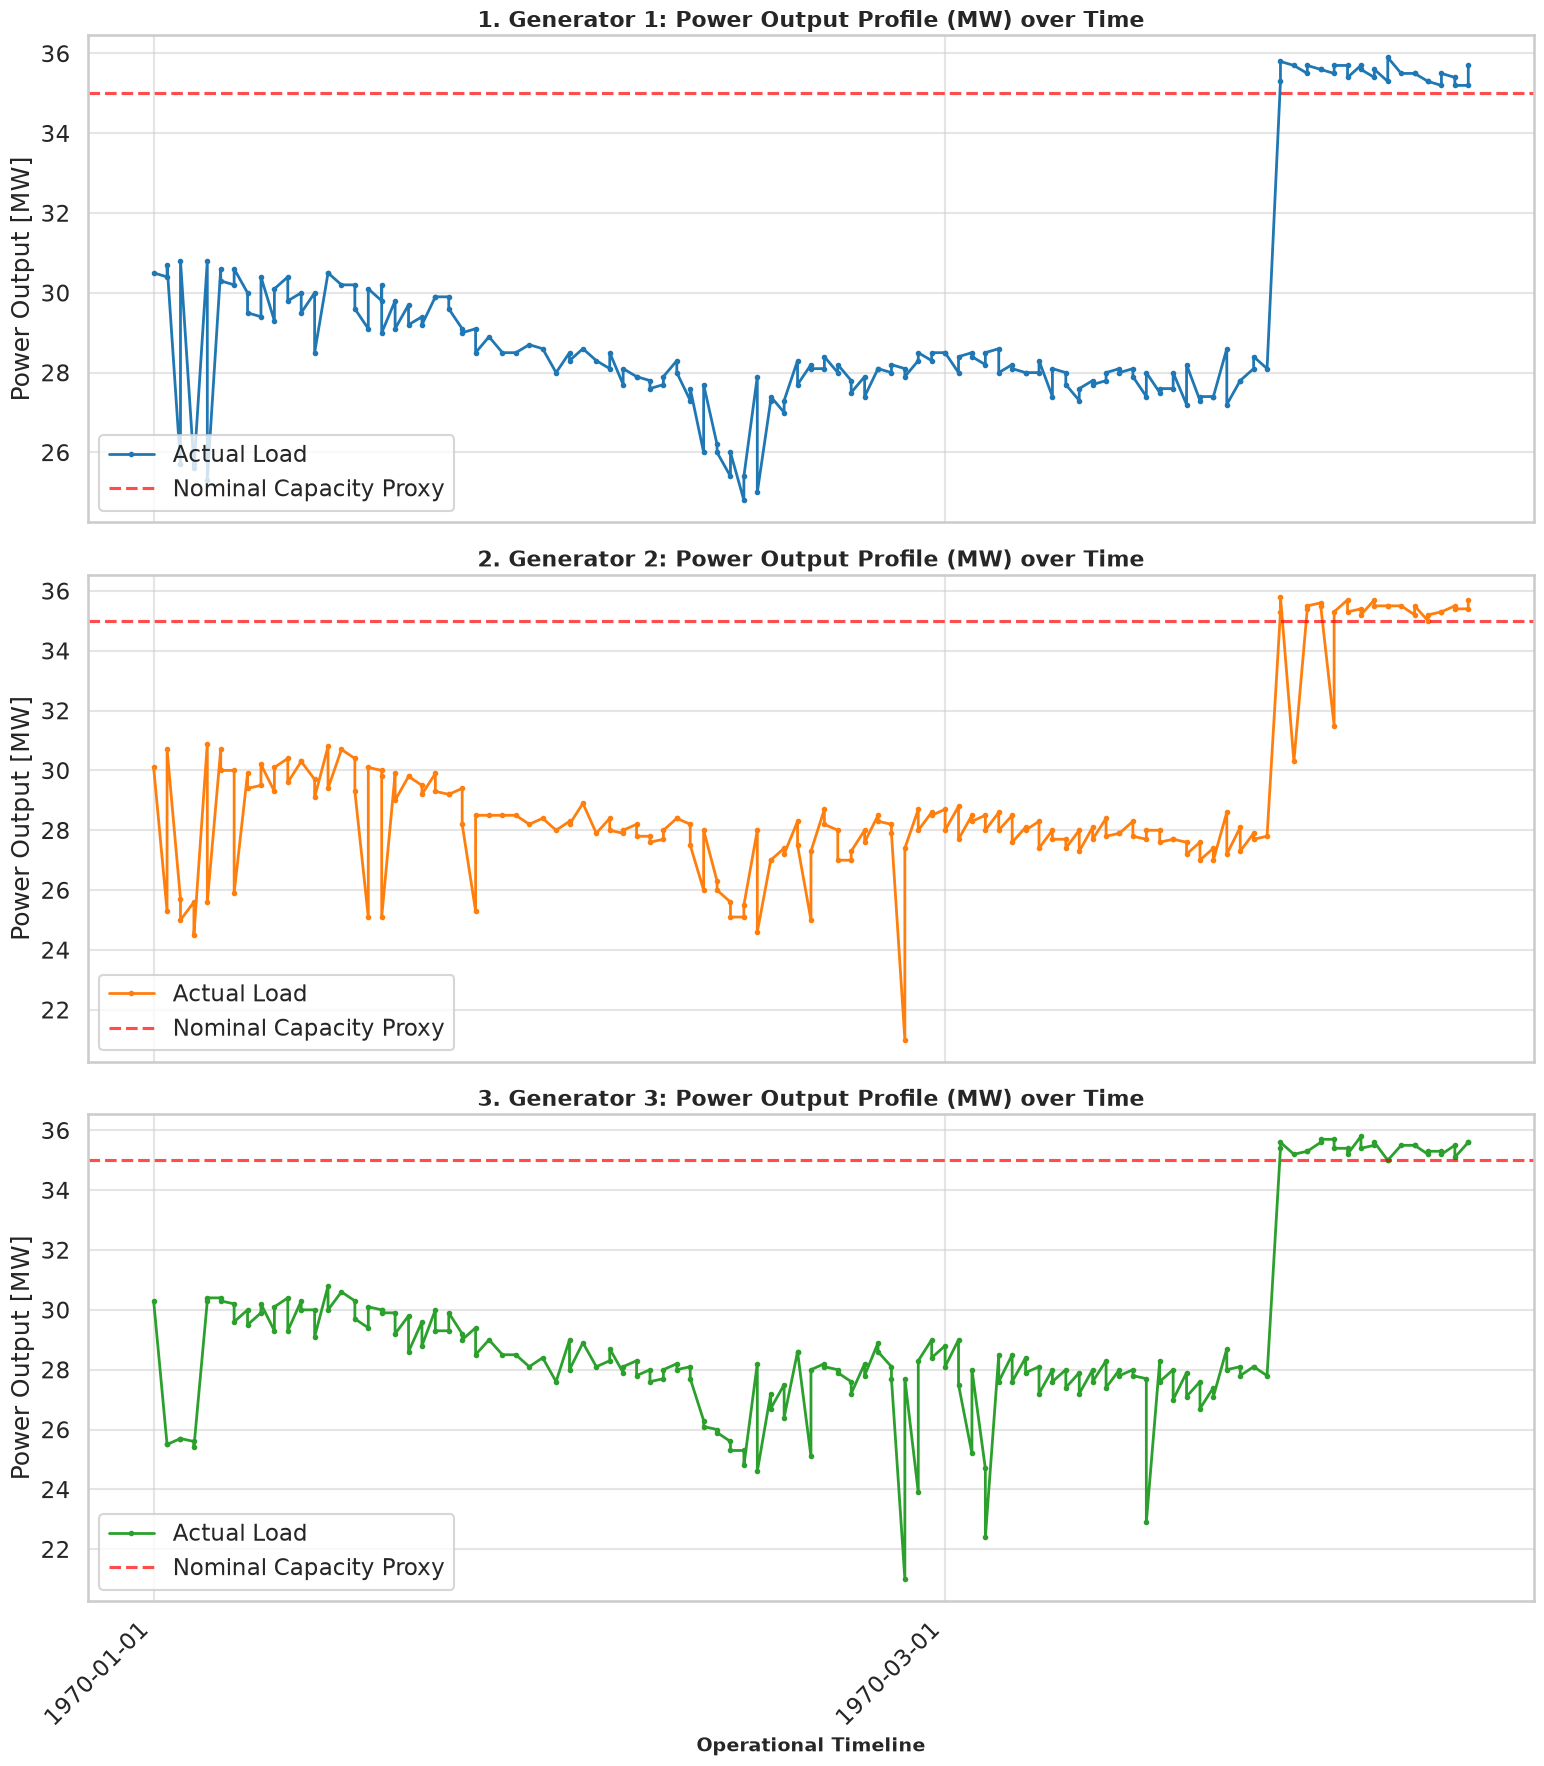

In [499]:
# Set a professional plotting style
sns.set_theme(style="whitegrid", context="talk")

# sharex=True locks the timelines together so they all align perfectly by date
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# 1. Generator 1 — Operational Load Profile
axes[0].plot(gen1_clean['date'], gen1_clean['load_MW'], color='#1f77b4', linewidth=2, marker='o', markersize=3, label='Actual Load')
axes[0].axhline(y=35.0, color='red', linestyle='--', alpha=0.7, label='Nominal Capacity Proxy')
axes[0].set_title('1. Generator 1: Power Output Profile (MW) over Time', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Power Output [MW]')
axes[0].legend(loc='lower left')

# 2. Generator 2 — Operational Load Profile
axes[1].plot(gen2_clean['date'], gen2_clean['load_MW'], color='#ff7f0e', linewidth=2, marker='o', markersize=3, label='Actual Load')
axes[1].axhline(y=35.0, color='red', linestyle='--', alpha=0.7, label='Nominal Capacity Proxy')
axes[1].set_title('2. Generator 2: Power Output Profile (MW) over Time', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Power Output [MW]')
axes[1].legend(loc='lower left')

# 3. Generator 3 — Operational Load Profile
axes[2].plot(gen3_clean['date'], gen3_clean['load_MW'], color='#2ca02c', linewidth=2, marker='o', markersize=3, label='Actual Load')
axes[2].axhline(y=35.0, color='red', linestyle='--', alpha=0.7, label='Nominal Capacity Proxy')
axes[2].set_title('3. Generator 3: Power Output Profile (MW) over Time', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Power Output [MW]')
axes[2].legend(loc='lower left')

# ─── THE X-AXIS FIXES (Applied only to the bottom axis, axes[2]) ───
# Rotate the dates so they never overlap
plt.xticks(rotation=45, ha='right')

# Force a tick mark exactly every 2 months instead of printing every single date row
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[2].set_xlabel('Operational Timeline', fontsize=14, fontweight='bold')

# Set tight layout so the rotated text doesn't get cut off at the very bottom
plt.tight_layout()
plt.show()

In [500]:
# Define nominal design capacity for an Olkaria II unit
NOMINAL_CAPACITY_MW = 35.0

def generate_unit_profile(df, name):
    # Calculate key high-grade engineering metrics
    mean_load = df['load_MW'].mean()
    max_load = df['load_MW'].max()
    min_load = df['load_MW'].min()
    std_dev = df['load_MW'].std()

    # Capacity Factor = (Average Power Generated / Nominal Design Capacity) * 100
    capacity_factor = (mean_load / NOMINAL_CAPACITY_MW) * 100

    # Off-Design Volatility Coefficient (Relative standard deviation)
    volatility_coef = (std_dev / mean_load) * 100

    # Time spent severely derated (Operating below 30 MW)
    derated_time_pct = (df['load_MW'] < 30.0).mean() * 100

    profile = {
        "Unit Baseline": name,
        "Mean Output (MW)": round(mean_load, 2),
        "Max Output (MW)": round(max_load, 2),
        "Min Output (MW)": round(min_load, 2),
        "Standard Deviation (MW)": round(std_dev, 2),
        "Capacity Factor (%)": round(capacity_factor, 2),
        "Volatility Coef (%)": round(volatility_coef, 2),
        "Downtime/Derated Presence (%)": round(derated_time_pct, 2)
    }
    return profile

# Compile profiles for all three power stations
g1_prof = generate_unit_profile(gen1_raw, "Generator 1")
g2_prof = generate_unit_profile(gen2_raw, "Generator 2")
g3_prof = generate_unit_profile(gen3_raw, "Generator 3")

# Display as a clean comparative engineering table
df_profiles = pd.DataFrame([g1_prof, g2_prof, g3_prof])
display(df_profiles)

,Unit Baseline,Mean Output (MW),Max Output (MW),Min Output (MW),Standard Deviation (MW),Capacity Factor (%),Volatility Coef (%),Downtime/Derated Presence (%)
0,Generator 1,29.41,35.9,24.8,2.82,84.02,9.57,73.66
1,Generator 2,29.10,35.8,21.0,2.91,83.15,10.02,76.34
2,Generator 3,29.15,35.8,21.0,3.04,83.28,10.43,73.66
